Variant 1

/tmp/ipykernel_6876/2848742487.py:37: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


Shape: (2700, 32738)
Classes: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8'}
0 4.081914999905755 4.2984864711761475 0.4203703703703704
1 3.347777387675117 4.041017055511475 0.6925925925925925
2 2.7706049610586727 3.9308423519134523 0.7611111111111111
3 2.3013891893274643 3.8273926258087156 0.8092592592592592
4 1.9496561323895174 3.949323034286499 0.8314814814814815
5 1.6842861526152666 3.913287305831909 0.8407407407407408
6 1.4199395074563868 4.026685905456543 0.8351851851851851
7 1.2192664181484896 4.2698181629180905 0.8425925925925926
8 1.0413912359405966 4.2418694496154785 0.8481481481481481
Early stopping


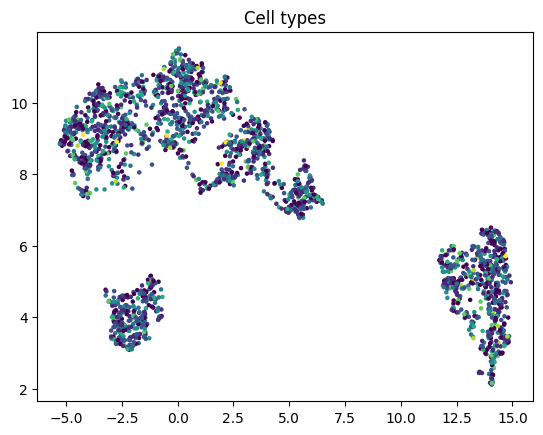

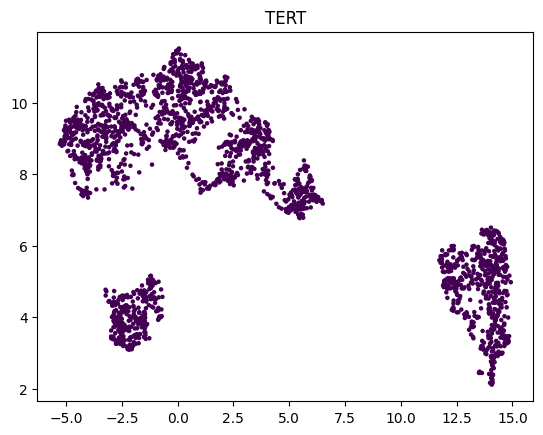

In [ ]:
# ======================
# INSTALL
# ======================
!pip install -q scanpy umap-learn scikit-learn matplotlib torch
!pip install -q python-igraph leidenalg

# ======================
# IMPORTS
# ======================
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import umap
import scanpy as sc

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ======================
# LOAD DATA
# ======================
adata = sc.datasets.pbmc3k()

# clustering (Leiden вместо Louvain)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata, resolution=0.5)

X_raw = adata.X.toarray()
genes = adata.var_names.tolist()

print("Shape:", X_raw.shape)

# ======================
# PREPROCESSING
# ======================
X_log = np.log1p(X_raw)
X_scaled = StandardScaler().fit_transform(X_log)

df_genes = pd.DataFrame(X_scaled, columns=genes)

# ======================
# GENE SETS
# ======================
def gene_score(df, geneset):
    g = [x for x in geneset if x in df.columns]
    if len(g) == 0:
        return np.zeros(len(df))
    return df[g].mean(axis=1).values

stress = gene_score(df_genes, ["HIF1A","HSPA1A","DNAJB1","ATF4","DDIT3"])
immune = gene_score(df_genes, ["CD4","CD8A","IFNG","IL2RA","STAT1"])
apoptosis = gene_score(df_genes, ["BAX","CASP3","TP53","CASP8","BCL2"])

# TERT or proxy
if "TERT" in df_genes.columns:
    tert = df_genes["TERT"].values
    tert_name = "TERT"
else:
    tert = gene_score(df_genes, ["MKI67","TOP2A","PCNA"])
    tert_name = "Proliferation proxy"

# normalize targets
def norm(x):
    return StandardScaler().fit_transform(x.reshape(-1,1)).squeeze()

y_reg = {
    "stress": norm(stress),
    "immune": norm(immune),
    "apoptosis": norm(apoptosis),
    "tert": norm(tert),
}

# ======================
# LABEL ENCODER (FIXED)
# ======================
le = LabelEncoder()
cell_type = le.fit_transform(adata.obs["leiden"].astype(str))

print("Classes:", dict(enumerate(le.classes_)))

# ======================
# PCA
# ======================
X_model = PCA(200).fit_transform(X_scaled)

# ======================
# SPLIT
# ======================
idx = np.arange(len(X_model))
train_idx, val_idx = train_test_split(idx, test_size=0.2, stratify=cell_type)

X_train, X_val = X_model[train_idx], X_model[val_idx]
y_reg_train = {k:v[train_idx] for k,v in y_reg.items()}
y_reg_val = {k:v[val_idx] for k,v in y_reg.items()}
y_cls_train, y_cls_val = cell_type[train_idx], cell_type[val_idx]

# ======================
# DATASET
# ======================
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y_reg, y_cls):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_reg = {k: torch.tensor(v, dtype=torch.float32) for k,v in y_reg.items()}
        self.y_cls = torch.tensor(y_cls, dtype=torch.long)

    def __len__(self): return len(self.X)

    def __getitem__(self, i):
        return {
            "x": self.X[i],
            "y_reg": {k:v[i] for k,v in self.y_reg.items()},
            "y_cls": self.y_cls[i]
        }

train_loader = torch.utils.data.DataLoader(Dataset(X_train,y_reg_train,y_cls_train), batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(Dataset(X_val,y_reg_val,y_cls_val), batch_size=128)

# ======================
# MODEL
# ======================
class Model(nn.Module):
    def __init__(self, inp, n_classes):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(inp,256),
            nn.ReLU(),
            nn.Linear(256,64),
            nn.ReLU()
        )
        self.z = nn.Linear(64,16)

        self.h1 = nn.Linear(16,1)
        self.h2 = nn.Linear(16,1)
        self.h3 = nn.Linear(16,1)
        self.h4 = nn.Linear(16,1)
        self.cls = nn.Linear(16,n_classes)

    def forward(self,x):
        h = self.enc(x)
        z = self.z(h)
        return {
            "stress": self.h1(z).squeeze(),
            "immune": self.h2(z).squeeze(),
            "apoptosis": self.h3(z).squeeze(),
            "tert": self.h4(z).squeeze(),
            "logits": self.cls(z),
            "z": z
        }

# ======================
# TRAIN
# ======================
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Model(X_model.shape[1], len(le.classes_)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

mse = nn.MSELoss()
ce = nn.CrossEntropyLoss()

def run(loader, train=True):
    model.train() if train else model.eval()
    tot, acc, n = 0,0,0

    for b in loader:
        x = b["x"].to(device)
        yr = {k:v.to(device) for k,v in b["y_reg"].items()}
        yc = b["y_cls"].to(device)

        if train: opt.zero_grad()

        pred = model(x)

        loss = (
            mse(pred["stress"], yr["stress"]) +
            mse(pred["immune"], yr["immune"]) +
            mse(pred["apoptosis"], yr["apoptosis"]) +
            mse(pred["tert"], yr["tert"]) +
            0.5*ce(pred["logits"], yc)
        )

        if train:
            loss.backward()
            opt.step()

        tot += loss.item()
        acc += (pred["logits"].argmax(1)==yc).sum().item()
        n += len(x)

    return tot/len(loader), acc/n

best = 1e9
patience = 5
wait = 0

for e in range(30):
    tr_loss,tr_acc = run(train_loader,True)
    val_loss,val_acc = run(val_loader,False)

    print(e, tr_loss, val_loss, val_acc)

    if val_loss < best:
        best = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping")
            break

model.load_state_dict(best_state)

# ======================
# UMAP
# ======================
model.eval()
Z = []

with torch.no_grad():
    for b in train_loader:
        Z.append(model(b["x"].to(device))["z"].cpu())

z = torch.cat(Z).numpy()
z2 = umap.UMAP().fit_transform(z)

# cell types
plt.scatter(z2[:,0], z2[:,1], c=adata.obs["leiden"].astype(int)[:len(z2)], s=5)
plt.title("Cell types")
plt.show()

# tert
plt.scatter(z2[:,0], z2[:,1], c=y_reg["tert"][:len(z2)], s=5)
plt.title(tert_name)
plt.show()